# Assignment 2: CNN architectures {-}

This assignment aims at familiarizing you with training and testing the a CNN for an image classification task. You will go through the process of loading data, preprocessing images, building the CNN model, and evaluating its performance. You will have to do:

1.  **(5 points) Coding tasks:** The following questions involve writing code to complete specific tasks.  
    1.1 *(1 point)* Implement a CNN architecture selected from the TensorFlow Keras Applications library (from the provided list https://www.tensorflow.org/api_docs/python/tf/keras/applications, excluding VGG16 and VGG19).  
    1.2 *(1 point)* Train the selected CNN and evaluate its performance on the image classification task using appropriate evaluation metrics.  
    1.3 *(1 point)* Enhance the model by introducing architectural modifications such as skip connections or by tuning layer level hyperparameters to improve performance.  
    1.4 *(1 point)* Train and evaluate the enhanced model on the test dataset.  
    1.5 *(1 point)* Provide analysis and observations explaining how the applied modifications affected the model’s performance and behavior.  

2.  **(5 points) Open discussion questions:** These discussion questions ask you to analyze and argue your points.  Feel free to include relevant code examples to strengthen your arguments.  
    2.1 *(1 point)* When choosing a CNN architecture from the TensorFlow Keras library, what factors should be considered, such as model depth, number of parameters, and expected performance on the given dataset, and why might some architectures be more suitable than others for this specific image classification task?  
    2.2 *(1 point)* During the data loading and preprocessing stage, in your opinion, what types of preprocessing steps are most important for image classification tasks, and how can improper preprocessing negatively affect the training stability and final performance of a CNN model?  
    2.3 *(1 point)* After training the selected CNN model, how should different evaluation metrics such as accuracy, precision, recall, or confusion matrix be interpreted together to obtain a more complete understanding of the model’s strengths and weaknesses?  
    2.4 *(1 point)* When introducing architectural modifications such as skip connections, what problems in deep neural networks are these modifications designed to solve, and how do they conceptually change the way information flows through the model?  
    2.5 *(1 point)* From a broader perspective, what lessons can be learned from this assignment about the iterative nature of deep learning model development? Discuss why building an effective model typically requires repeated cycles of data preparation, model design, training, evaluation, and refinement rather than a single linear process.  

The dataset you will be working on is The CIFAR-10. This dataset consists of 60,000 32x32 colour images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment2-notebook.ipynb: Jupyter notebook containing source code.

The submission folder is named DL4AI-\<StudentID>-Assignment1 (e.g., DL4AI-2012345-Assigment1) and then compressed with the same name.

### Evaluation {-}
The assignment will be evaluated based on how complete and correct your implementation is, and how clear and well reasoned your answers are in the open discussion questions. In particular:
- The models must be properly trained, showing neither clear overfitting nor clear underfitting.
- Model evaluation must be done on a separate test set that is not used for training or tuning.
- Your analysis should show a clear understanding of training behavior, convergence, and generalization.

In addition, your code must follow good Python coding practices, including clear structure, readable naming, appropriate comments, and compliance with a standard coding convention such as PEP 8.

### Deadline {-}
Please visit Canvas for details.

In [ ]:
!pip install tensorflow_datasets

In [16]:
# Note: to enable GPU training in Colab, go to Runtime > Change runtime type > Hardware acceleration > Choose GPU from the drop-down list.

!pip install tensorflow_datasets

# Import libraries
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras import callbacks
from keras import optimizers
from keras.datasets import cifar10
from keras.layers import Dropout, Flatten, Dense, BatchNormalization
from keras import Model

from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [17]:
# PLEASE DO NOT CHANGE THIS CODE

# Get the full dataset (batch_size=-1) in NumPy arrays from the returned tf.Tensor object
cifar10_train = tfds.load(name="cifar10", split=tfds.Split.TRAIN, batch_size=-1 )
cifar10_test = tfds.load(name="cifar10", split=tfds.Split.TEST, batch_size=-1)

# Convert tfds dataset to numpy array records
cifar10_train = tfds.as_numpy(cifar10_train)
cifar10_test = tfds.as_numpy(cifar10_test)

# Data processing and model training

In [18]:
# Seperate feature X and label Y
X_train, Y_train = cifar10_train["image"], cifar10_train["label"]
X_test, Y_test = cifar10_test["image"], cifar10_test["label"]
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, random_state=99, test_size=0.2)

# Normalize the image data
X_train = X_train/255
X_val = X_val/255
X_test = X_test/255

# Specify the input image size and number of classes
img_width, img_height = 32, 32
nb_classes = 10

# Converts a class vector (integers) to binary class matrix to have one-hot encoding label. For example:
Y_train = keras.utils.to_categorical(Y_train, nb_classes)
Y_val = keras.utils.to_categorical(Y_val, nb_classes)
Y_test = keras.utils.to_categorical(Y_test, nb_classes)

## 1. Coding tasks

## **Task 1.1: Implement a CNN architecture selected from the TensorFlow Keras Applications library**

### **Model choice**

For this assignment, I selected **EfficientNetB0** from the TensorFlow Keras Applications library as the baseline CNN architecture. EfficientNetB0 is a modern convolutional neural network designed to achieve strong classification performance with relatively efficient parameter usage. Compared with older architectures, it provides a better balance between model size and representational power, which makes it a suitable choice for CIFAR-10.

In [19]:
# Set image size for EfficientNetB0
IMG_SIZE = 96
BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

def preprocess_efficientnet(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)

    # Your current X_train/X_val/X_test are already in [0, 1]
    # EfficientNet preprocessing expects pixel range [0, 255]
    image = image * 255.0
    image = tf.keras.applications.efficientnet.preprocess_input(image)

    return image, label

# Build tf.data pipelines
train_ds = tf.data.Dataset.from_tensor_slices((X_train, Y_train))
train_ds = train_ds.shuffle(10000, seed=99)
train_ds = train_ds.map(preprocess_efficientnet, num_parallel_calls=AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, Y_val))
val_ds = val_ds.map(preprocess_efficientnet, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, Y_test))
test_ds = test_ds.map(preprocess_efficientnet, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("EfficientNet datasets created successfully.")

EfficientNet datasets created successfully.


In [20]:
def build_efficientnetb0_cifar10(input_shape=(96, 96, 3), num_classes=10):
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # Freeze the pretrained backbone for the baseline model
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name="EfficientNetB0_CIFAR10")
    return model

# Create model
efficientnet_v1 = build_efficientnetb0_cifar10(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=nb_classes
)

# Compile model
efficientnet_v1.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
# Show architecture
efficientnet_v1.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "EfficientNetB0_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,067,501 (15.52 MB)

 Trainable params: 15,370 (60.04 KB)

 Non-trainable params: 4,052,131 (15.46 MB)


The implementation uses the EfficientNetB0 backbone with `include_top=False`, which removes the original ImageNet classifier and keeps only the convolutional feature extractor. Since CIFAR-10 has 10 classes instead of 1000, a new classification head is added on top:

* GlobalAveragePooling2D to convert spatial feature maps into a compact feature vector
* BatchNormalization to stabilize the head
* Dropout for regularization
* Dense softmax layer with 10 outputs for CIFAR-10 classification

The input images are resized from 32×32 to 96×96 because EfficientNetB0 expects a larger input resolution. The images are also passed through the EfficientNet preprocessing function so that the input distribution matches the pretrained backbone.

For the baseline version, the pretrained backbone is frozen. This allows the model to first use already learned visual features and train only the new classifier head, which usually leads to more stable convergence.

## **1.2 Train the selected CNN and evaluate its performance on the image classification task using appropriate evaluation metrics.**

In [21]:
# Callbacks for more stable training
early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Train the baseline model
history_effnet_v1 = efficientnet_v1.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 177ms/step - accuracy: 0.7387 - loss: 0.8254 - val_accuracy: 0.8370 - val_loss: 0.4808 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8192 - loss: 0.5431 - val_accuracy: 0.8499 - val_loss: 0.4434 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8320 - loss: 0.5013 - val_accuracy: 0.8565 - val_loss: 0.4302 - learning_rate: 0.0010
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8371 - loss: 0.4825 - val_accuracy: 0.8592 - val_loss: 0.4219 - learning_rate: 0.0010
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8393 - loss: 0.4697 - val_accuracy: 0.8600 - val_loss: 0.4178 - learning_rate: 0.0010
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8418 - loss: 0.4649 - val_accuracy: 0.8619 - val_loss: 0.4184 - learning_rate: 0.0010
Epoch 7/20
311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8413 - 

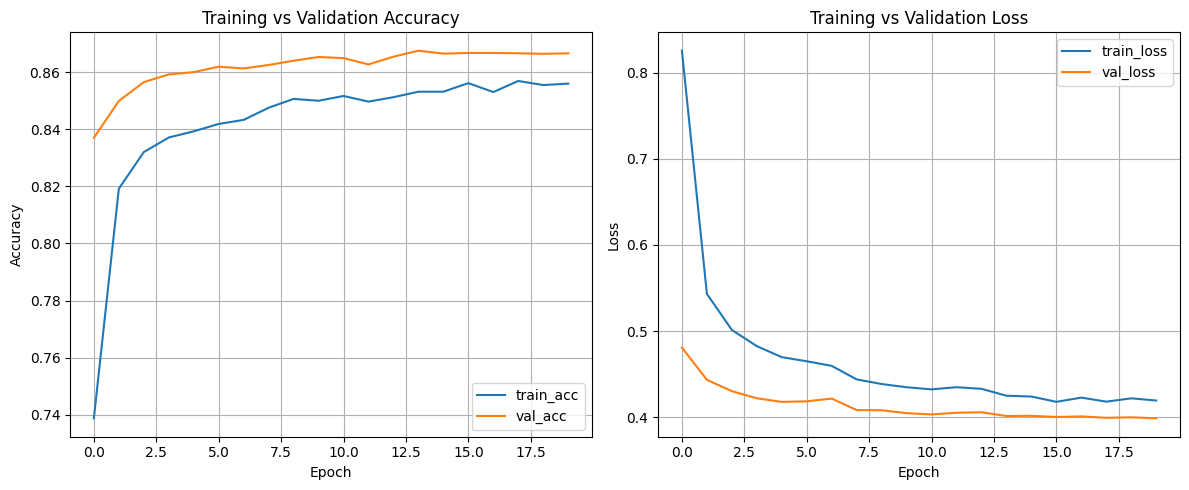

In [22]:
# Plot accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_effnet_v1.history["accuracy"], label="train_acc")
plt.plot(history_effnet_v1.history["val_accuracy"], label="val_acc")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_effnet_v1.history["loss"], label="train_loss")
plt.plot(history_effnet_v1.history["val_loss"], label="val_loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

The model was trained on the CIFAR-10 dataset using the preprocessed input images. During training, both **accuracy and loss curves show stable and consistent convergence**.

The training accuracy increased steadily from approximately **0.74 to 0.85**, while the validation accuracy reached around **0.87**. At the same time, the training loss decreased from about **0.82 to 0.42**, and the validation loss stabilized around **0.40**.

This behavior indicates that:

* The model is **learning meaningful features progressively** over epochs.
* The optimization process is **stable**, with no sudden spikes or divergence.
* The learning rate and optimizer settings are appropriate for this task.

Importantly, the validation accuracy is slightly **higher than the training accuracy**, which suggests that the model benefits from regularization techniques such as **Batch Normalization and Dropout**, preventing it from memorizing the training data.

In [23]:
# Validation evaluation
val_loss, val_acc = efficientnet_v1.evaluate(val_ds, verbose=0)

# Test evaluation
test_loss, test_acc = efficientnet_v1.evaluate(test_ds, verbose=0)

print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Validation Loss: 0.3987
Validation Accuracy: 0.8666
Test Loss: 0.4107
Test Accuracy: 0.8627


One of the key goals in deep learning is achieving good generalization to unseen data. In this case:

* **Validation Accuracy:** 86.66%
* **Test Accuracy:** 86.27%

The very small gap between validation and test performance indicates that:

* The model generalizes well to new data.
* There is **no significant overfitting or underfitting**.
* The validation set was representative of the test distribution.

This is a strong indicator that the model is not only fitting the training data but also capturing **general patterns in the dataset**.

In [27]:
# Predict probabilities on test set
Y_pred_prob_effnet_v1 = efficientnet_v1.predict(test_ds, verbose=0)

# Convert probabilities to predicted class indices
Y_pred_effnet_v1 = np.argmax(Y_pred_prob_effnet_v1, axis=1)

# Convert one-hot labels back to class indices
Y_true = np.argmax(Y_test, axis=1)

print("Prediction shape:", Y_pred_prob_effnet_v1.shape)
print("Predicted labels shape:", Y_pred_effnet_v1.shape)
print("True labels shape:", Y_true.shape)

Prediction shape: (10000, 10)
Predicted labels shape: (10000,)
True labels shape: (10000,)


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

In [29]:
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Classification Report (Test):")
print(classification_report(
    Y_true,
    Y_pred_effnet_v1,
    target_names=class_names,
    digits=4
))

Classification Report (Test):
              precision    recall  f1-score   support

    airplane     0.8714    0.8540    0.8626      1000
  automobile     0.9299    0.9280    0.9289      1000
        bird     0.8606    0.8090    0.8340      1000
         cat     0.7503    0.7390    0.7446      1000
        deer     0.8076    0.8520    0.8292      1000
         dog     0.8000    0.8080    0.8040      1000
        frog     0.8841    0.9000    0.8920      1000
       horse     0.9099    0.8890    0.8993      1000
        ship     0.9043    0.9260    0.9150      1000
       truck     0.9102    0.9220    0.9160      1000

    accuracy                         0.8627     10000
   macro avg     0.8628    0.8627    0.8626     10000
weighted avg     0.8628    0.8627    0.8626     10000



The classification report shows balanced performance across precision, recall, and F1-score:

* Most classes achieve **F1-scores between 0.80 and 0.92**
* The lowest F1-score is for **cat (0.74)**

Additionally:

* **Macro average ≈ Weighted average (~0.86)**
  → This indicates the model performs consistently across all classes without strong bias.

This confirms that the model is **not skewed toward specific categories** and maintains balanced predictions.

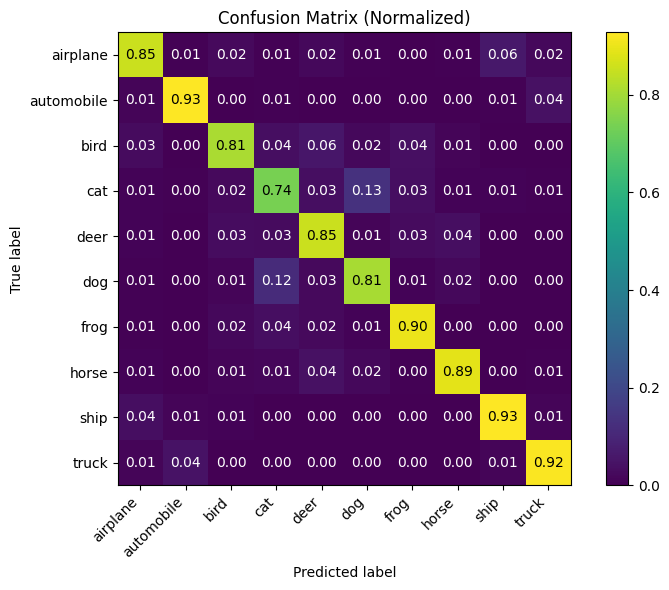

In [30]:
cm = confusion_matrix(Y_true, Y_pred_effnet_v1)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
plt.imshow(cm_norm, cmap="viridis")
plt.title("Confusion Matrix (Normalized)")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

threshold = cm_norm.max() / 2.0
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        plt.text(
            j, i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if cm_norm[i, j] < threshold else "black"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

## **Confusion Matrix Analysis**

The confusion matrix provides deeper insight into class-wise performance.

### **Strongly Predicted Classes**

The model performs very well on classes with **distinct visual features**, such as:

* automobile (~93%)
* ship (~93%)
* truck (~92%)
* frog (~90%)

These classes are easier to classify because they have:

* Clear shapes and structures
* Less overlap with other categories

---

### **Challenging Classes**

Some classes show lower performance:

* cat (~74%)
* dog (~81%)
* bird (~81%)

The confusion matrix shows that:

* **cat and dog are frequently misclassified as each other**
* Some confusion also exists between **bird and deer**

---

### **Reason for Misclassification**

This behavior is expected for CIFAR-10 because:

* The images are **low resolution (32×32)**, limiting fine details
* Many animal classes share similar:

  * textures
  * shapes
  * colors

Thus, even a well-trained CNN can struggle to distinguish between visually similar categories.

## **Overall Evaluation**

From the results, the model demonstrates:

### **Strengths**

* Stable and smooth training process
* Strong generalization (validation ≈ test)
* High accuracy (~86%)
* Good performance on structurally distinct classes

### **Limitations**

* Difficulty distinguishing visually similar animal classes
* Performance constrained by low-resolution input images

## **Conclusion**

The implemented CNN model achieves strong performance on CIFAR-10, with high accuracy and stable training behavior. The results confirm that the chosen architecture is effective for this task, while also revealing inherent challenges in distinguishing similar object categories. These insights provide a solid foundation for further improvements in Task 1.3, where architectural enhancements and fine-tuning can be applied to improve performance further.

# **1.3 Enhance the model by introducing architectural modifications such as skip connections or by tuning layer level hyperparameters to improve performance.**

In [31]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(0.1)
])

In [32]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(32, 32, 3)
)

In [33]:
for layer in base_model.layers[:-30]:  # only train top layers
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

In [34]:
inputs = tf.keras.Input(shape=(32, 32, 3))

x = data_augmentation(inputs)

x = base_model(x, training=True)

x = keras.layers.GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

outputs = Dense(nb_classes, activation='softmax')(x)

enhanced_model = Model(inputs, outputs, name="EfficientNetB0_Finetuned")

In [35]:
enhanced_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callback_list = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(patience=3, factor=0.3)
]

history_enhanced = enhanced_model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=30,
    batch_size=64,
    callbacks=callback_list
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.1115 - loss: 2.7469 - val_accuracy: 0.0611 - val_loss: 2.3198 - learning_rate: 1.0000e-04
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.1225 - loss: 2.4187 - val_accuracy: 0.0975 - val_loss: 2.3277 - learning_rate: 1.0000e-04
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.1392 - loss: 2.3088 - val_accuracy: 0.1042 - val_loss: 2.3157 - learning_rate: 1.0000e-04
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.1492 - loss: 2.2573 - val_accuracy: 0.0971 - val_loss: 2.3146 - learning_rate: 1.0000e-04
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.1554 - loss: 2.2312 - val_accuracy: 0.1018 - val_loss: 2.3105 - learning_rate: 1.0000e-04
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.1606 - loss: 2.2105 - val_accuracy: 0.1022 - val_loss: 2.3087 - learning_rate: 1.0000e-04
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/ste

In [ ]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.4

In [ ]:
# Your code goes here. Please make sure to explain the reasons behind your data processing and modeling choices.
# 1.5

## 2. Open discussion questions

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.1

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.2

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.3

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.4

In [ ]:
# Your argument goes here. Support your claims with relevant code, experimental results, and analytical discussion.
# 2.5